# Exercises

| Attribute / Question        | Binomial                                          | Poisson                                            | Normal                                                        | Exponential                                              |
| --------------------------- | ------------------------------------------------- | -------------------------------------------------- | ------------------------------------------------------------- | -------------------------------------------------------- |
| **Data Type**               | Discrete                                          | Discrete                                           | Continuous                                                    | Continuous                                               |
| **When to Use**             | Counting successes in a fixed number of trials    | Counting events over a fixed interval (time/space) | Symmetric, central clustering                                 | Time or distance between events                          |
| **Example**                 | # defective items in a batch                      | # complaints per day                               | Heights, weights, delivery times                              | Time between purchases                                   |
| **Key Signals / Intuition** | Fixed n, 2 outcomes, probability roughly constant | Rare events, mean ≈ variance, independent events   | Bell-shaped, mean ≈ median, can take negative/positive values | Positive only, skewed right, long tail for larger values |
| **Scipy Stats Functions**   | `binom.pmf()`, `binom.cdf()`                      | `poisson.pmf()`, `poisson.cdf()`                   | `norm.pdf()`, `norm.cdf()`                                    | `expon.pdf()`, `expon.cdf()`                             |


# Use the following as a guide principle to solve the exercises


- Step 1: Identify data type → discrete or continuous.

- Step 2: Ask what you want to measure or predict → count vs. time vs. measurement.

- Step 3: Compute mean, variance, std → gives clues about distribution shape.

- Step 4: Plot histogram → see pattern.

- (optional)Step 5: Overlay theoretical curve (PDF/PMF) → check if real data matches expectations.

# Case Study 1 – Employee Heights

Scenario:
A company wants to understand employee heights for uniform sizes and ergonomic furniture. You have measured the heights of 500 employees.


Hint: Follow the steps in the overview and also use the table above.

In [ ]:
#Read the employee heights file

import numpy as np  # this will allows us to generate random data 
import pandas as pd 
import seaborn as sns # for plotting
import matplotlib.pyplot as plt # for plottinh
from scipy.stats import expon, norm  # our stats package that contains the functions, here we import expon specifically

In [3]:
df_employee_heights = pd.read_csv("../data/employee_heights.csv")

In [4]:
df_employee_heights.head()

,height
0,174.967142
1,168.617357
2,176.476885
3,185.230299
4,167.658466


In [5]:
df_employee_heights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   height  500 non-null    float64
dtypes: float64(1)
memory usage: 4.0 KB


In [6]:
mean_height = df_employee_heights["height"].mean()
std_dev_height =  df_employee_heights["height"].std()
median_height= df_employee_heights['height'].median()

In [7]:
print(f" the mean number of height are {mean_height}")
print(f" the standard deviation of height are {std_dev_height}")
print(f" the median number of height are {median_height}")

 the mean number of height are 170.0683799458865
 the standard deviation of height are 9.81253247361853
 the median number of height are 170.1279714632985


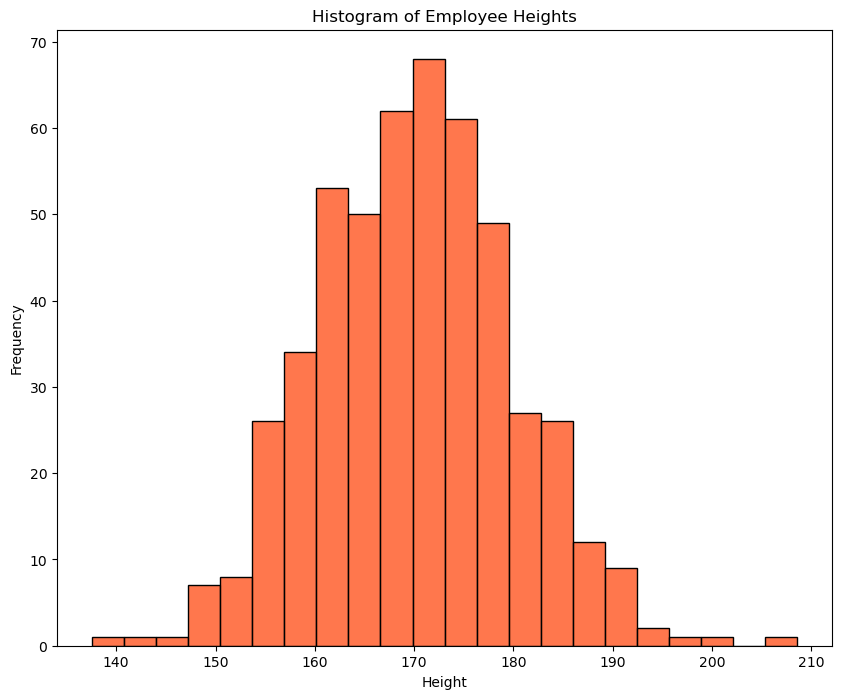

In [8]:
plt.figure(figsize=(10,8))
sns.histplot(df_employee_heights["height"], kde=False, color='#ff4a11ff')
plt.title('Histogram of Employee Heights')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.show()

[137.5873266  138.30389214 139.02045768 139.73702321 140.45358875
 141.17015429 141.88671983 142.60328537 143.31985091 144.03641645
 144.75298198 145.46954752 146.18611306 146.9026786  147.61924414
 148.33580968 149.05237521 149.76894075 150.48550629 151.20207183
 151.91863737 152.63520291 153.35176845 154.06833398 154.78489952
 155.50146506 156.2180306  156.93459614 157.65116168 158.36772721
 159.08429275 159.80085829 160.51742383 161.23398937 161.95055491
 162.66712045 163.38368598 164.10025152 164.81681706 165.5333826
 166.24994814 166.96651368 167.68307921 168.39964475 169.11621029
 169.83277583 170.54934137 171.26590691 171.98247245 172.69903798
 173.41560352 174.13216906 174.8487346  175.56530014 176.28186568
 176.99843121 177.71499675 178.43156229 179.14812783 179.86469337
 180.58125891 181.29782445 182.01438998 182.73095552 183.44752106
 184.1640866  184.88065214 185.59721768 186.31378321 187.03034875
 187.74691429 188.46347983 189.18004537 189.89661091 190.61317645
 191.329741

Text(0, 0.5, 'Probability Density')

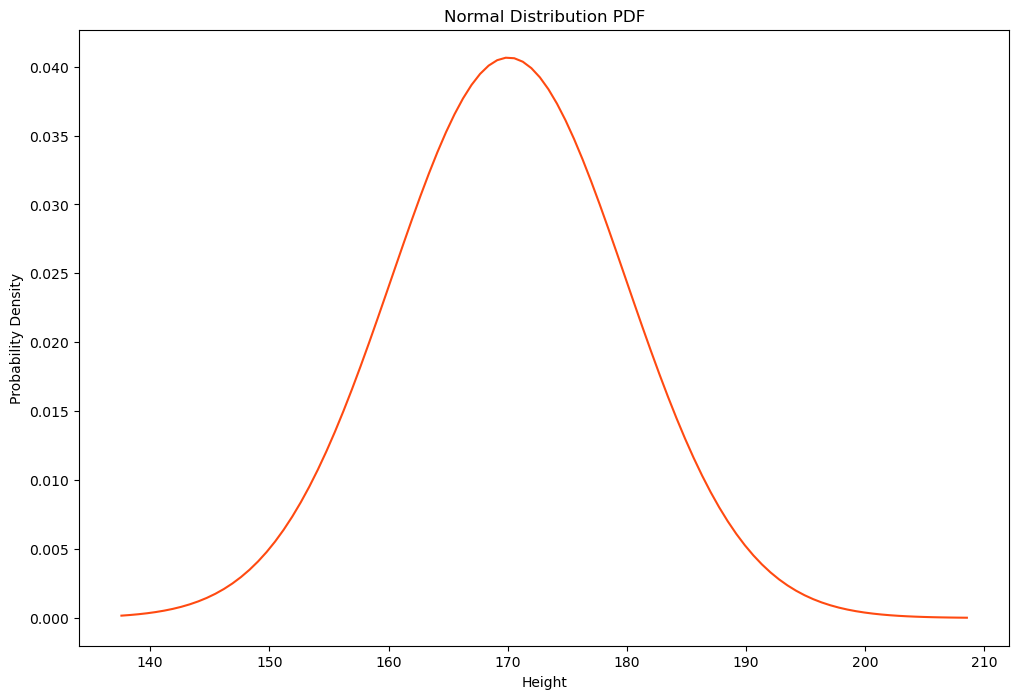

In [59]:
# Normal Distribution Plot
x = np.linspace(min(df_employee_heights['height']), max(df_employee_heights['height']), 100)
print(x)
pdf = norm.pdf(x, mean_height, std_dev_height)
plt.figure(figsize=(12,8))
plt.plot(x, pdf, color='#ff4a11ff')
plt.title('Normal Distribution PDF')
plt.xlabel('Height')
plt.ylabel('Probability Density')

# Case Study 2 – Call Center Call Volume

Scenario:
A call center wants to know the number of calls per hour during peak times. 

The goal is to understand the typical call volume and see how unusual high or low call counts are.

Hint: Follow the steps in the overview and also use the tables above

In [ ]:
# Read the calls dataset

from scipy.stats import poisson # our stats package that contains the functions, here we import poisson specifically

In [11]:
df_calls = pd.read_csv("../data/calls.csv")

In [12]:
df_calls.head()

,calls
0,6
1,7
2,7
3,4
4,9


In [13]:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   calls   100 non-null    int64
dtypes: int64(1)
memory usage: 932.0 bytes


In [14]:
mean_calls = df_calls["calls"].mean()
variance_calls = df_calls["calls"].var()

In [15]:
print(f" the mean number of calls are {mean_calls}")
print(f" the variance of calls are {variance_calls}")

 the mean number of calls are 7.9
 the variance of calls are 8.212121212121213


Text(0, 0.5, 'Frequency')

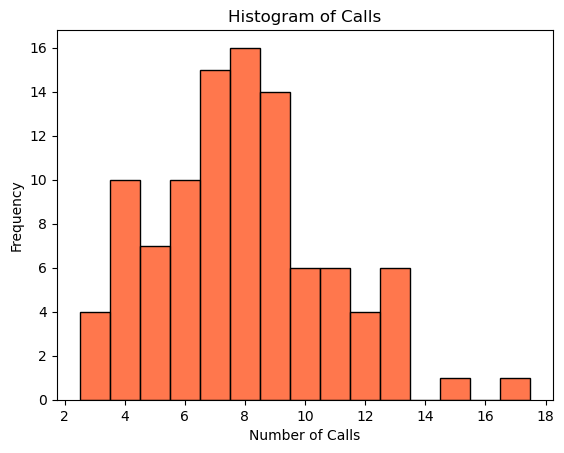

In [16]:
sns.histplot(df_calls["calls"], discrete=True, color='#ff4a11ff')
plt.title('Histogram of Calls')
plt.xlabel('Number of Calls')
plt.ylabel('Frequency')

In [17]:
x = np.arange(0, max(df_calls["calls"])+1) 

In [18]:
# from scipy.stats import poisson
# import numpy as np

# x = np.arange(df_calls["calls"].max() + 1)
# lambda_hat = df_calls["calls"].mean()
# pmf = poisson.pmf(x, lambda_hat)


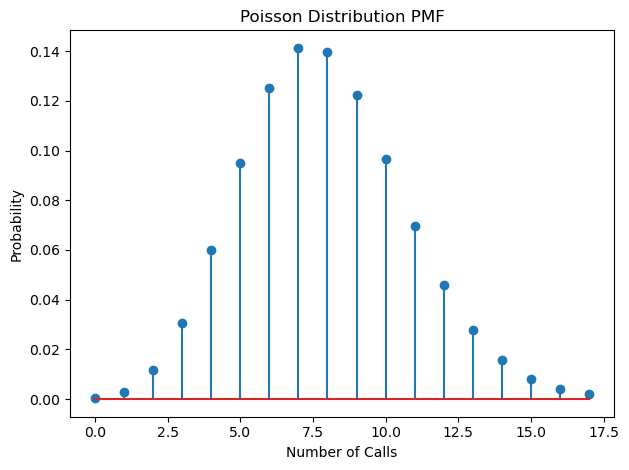

In [19]:
pmf = poisson.pmf(x, mean_calls)
plt.stem(x, pmf) # stem plot
plt.title('Poisson Distribution PMF')
plt.xlabel('Number of Calls')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

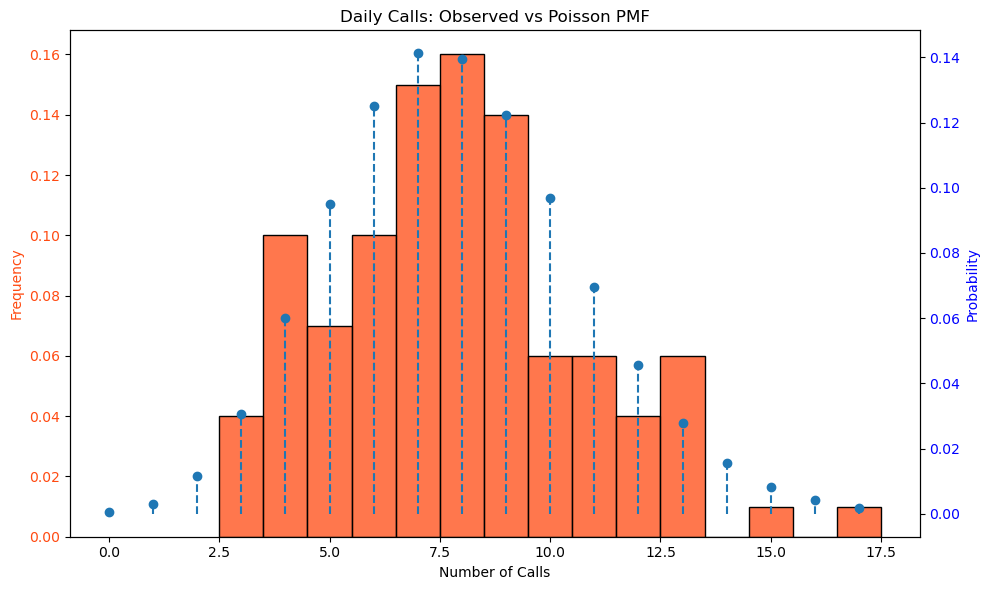

In [20]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Histogram (frequency)
sns.histplot(df_calls["calls"], discrete=True, color='#ff4a11ff', stat="probability", ax=ax1)
ax1.set_xlabel("Number of Calls")
ax1.set_ylabel("Frequency", color='#ff4a11ff')
ax1.tick_params(axis='y', labelcolor='#ff4a11ff')

# PMF on secondary y-axis
ax2 = ax1.twinx()
ax2.stem(x, pmf, basefmt=" ", linefmt='--', markerfmt='o', label='Poisson PMF')
ax2.set_ylabel("Probability", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Daily Calls: Observed vs Poisson PMF")
plt.tight_layout()
plt.show()

## Step 1: Data Type

Question: Are we counting events or measuring time?

Hint: Counts of calls are discrete events.

In [3]:
# Case Study 1 – Employee Heights: measuring attributes, the heights are continuous events
# Case Study 2 – Call Center Call Volume: counting events, the number of calls are discrete events

# BONUS Case Study – Analyzing Exam Scores

Scenario:
You want to understand students’ performance in a class. You have exam scores and want to know how typical or unusual each score is.

## Step 1: Understand the Data Type

Question: Are the exam scores discrete or continuous?

Hint: Can the values take any number within a range, or are they fixed counts?

In [ ]:
# Read the exam_scores data from the data folder

df_exam_scores = pd.read_csv("../data/exam_scores.csv")

In [32]:
df_exam_scores

,scores
0,85
1,90
2,78
3,92
4,88
5,95
6,70
7,60
8,82
9,75


In [43]:
df_exam_scores.sort_values(by='scores')

,scores
7,60
6,70
19,72
9,75
15,77
2,78
10,80
8,82
14,83
0,85


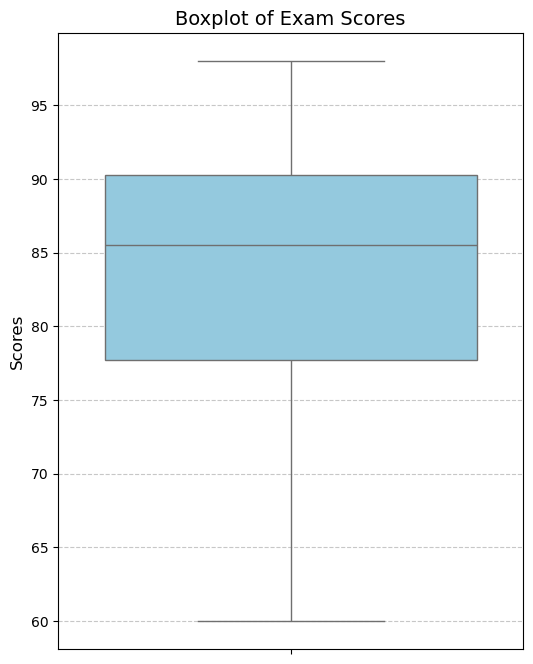

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))  # optional: makes the plot bigger
sns.boxplot(y=df_exam_scores['scores'], color='skyblue')  # color optional
plt.title('Boxplot of Exam Scores', fontsize=14)
plt.ylabel('Scores', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # optional: adds grid lines
plt.show()


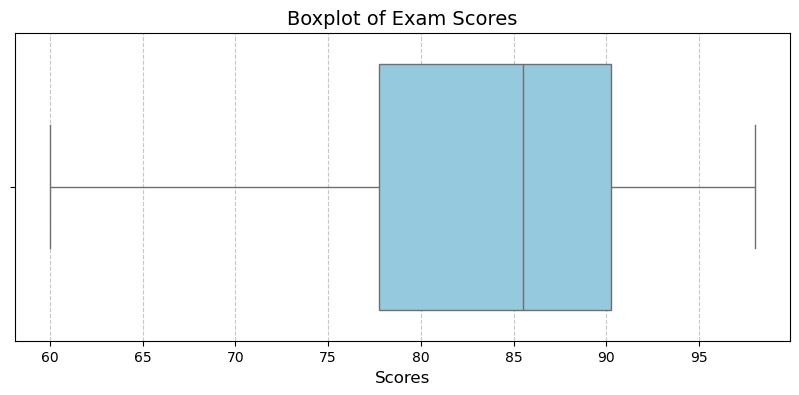

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))  # wider for horizontal plot
sns.boxplot(x=df_exam_scores['scores'], color='skyblue')  # note x= instead of y=
plt.title('Boxplot of Exam Scores', fontsize=14)
plt.xlabel('Scores', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [24]:
df_exam_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   scores  20 non-null     int64
dtypes: int64(1)
memory usage: 292.0 bytes


In [25]:
mean_exam_scores = df_exam_scores["scores"].mean()
std_dev_exam_scores =  df_exam_scores["scores"].std()
median_exam_scores= df_exam_scores['scores'].median()

In [31]:
print(f" the mean number of exam scores are {mean_exam_scores}")
print(f" the variance of exam scores are {std_dev_exam_scores}")
print(f" the median number of scores are {median_exam_scores}")

 the mean number of exam scores are 83.65
 the variance of exam scores are 9.538150543447806
 the median number of scores are 85.5


Text(0, 0.5, 'Frequency')

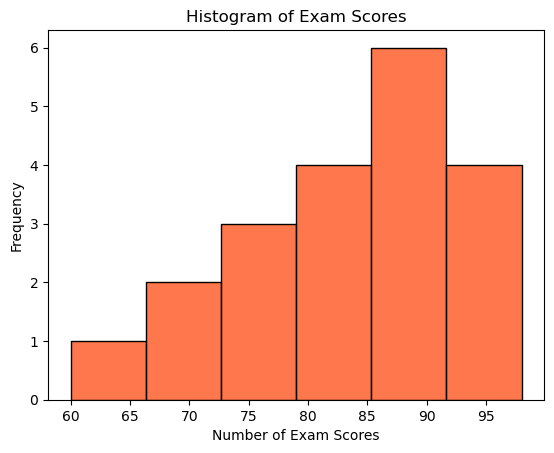

In [41]:
sns.histplot(df_exam_scores["scores"], color='#ff4a11ff')
plt.title('Histogram of Exam Scores')
plt.xlabel('Number of Exam Scores')
plt.ylabel('Frequency')

Text(0, 0.5, 'Probability Density')

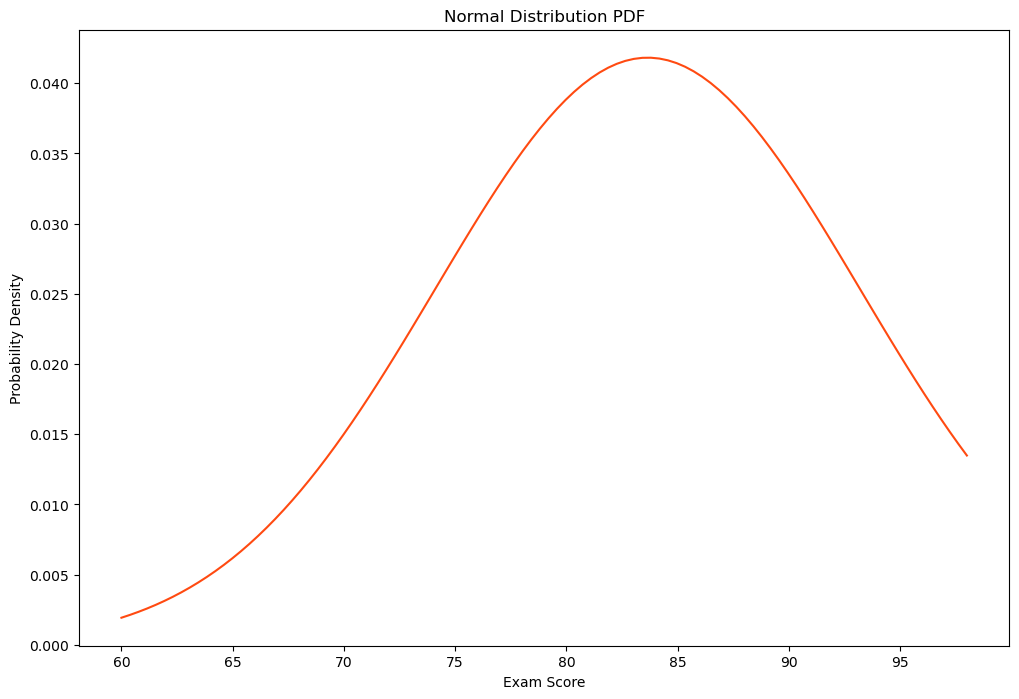

In [29]:
# Normal Distribution Plot
x = np.linspace(min(df_exam_scores['scores']), max(df_exam_scores['scores']), 100)
pdf = norm.pdf(x, mean_exam_scores, std_dev_exam_scores)
plt.figure(figsize=(12,8))
plt.plot(x, pdf, color='#ff4a11ff')
plt.title('Normal Distribution PDF')
plt.xlabel('Exam Score')
plt.ylabel('Probability Density')

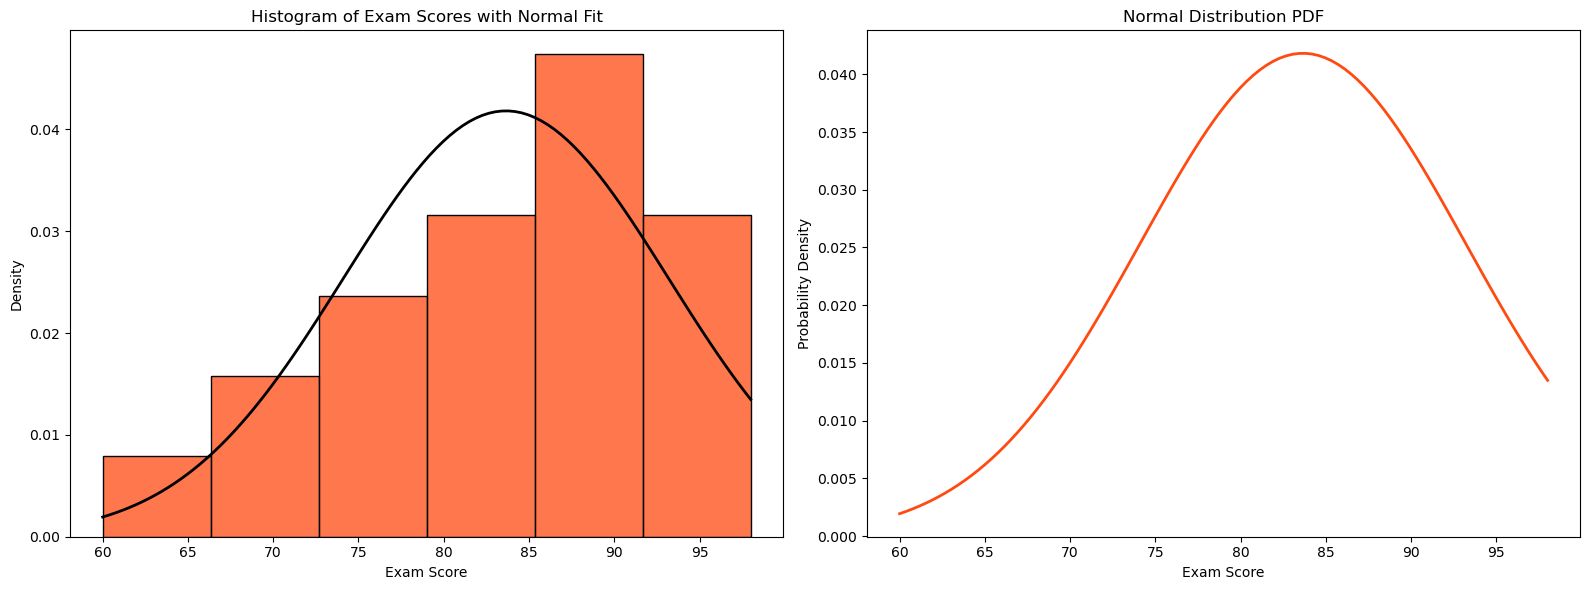

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Prepare values for PDF
x = np.linspace(min(df_exam_scores['scores']), max(df_exam_scores['scores']), 100)
pdf = norm.pdf(x, mean_exam_scores, std_dev_exam_scores)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Histogram with normal PDF overlay ---
sns.histplot(df_exam_scores["scores"], color='#ff4a11ff', stat='density', ax=axes[0])
axes[0].plot(x, pdf, color='black', linewidth=2)
axes[0].set_title('Histogram of Exam Scores with Normal Fit')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Density')

# --- Right: Normal distribution PDF only ---
axes[1].plot(x, pdf, color='#ff4a11ff', linewidth=2)
axes[1].set_title('Normal Distribution PDF')
axes[1].set_xlabel('Exam Score')
axes[1].set_ylabel('Probability Density')

plt.tight_layout()
plt.show()


## play around, not relevant to the excises

In [ ]:
n, p = 10, 0.3
x_binom = np.arange(0, n+1)
y_binom = binom.pmf(x_binom, n, p)
plt.bar(x_binom, y_binom, alpha=0.6, color='blue')
plt.title('二项分布 (n=10, p=0.3)')
plt.xlabel('成功次数')
plt.ylabel('概率')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39033 (\N{CJK UNIFIED IDEOGRAPH-9879}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/I

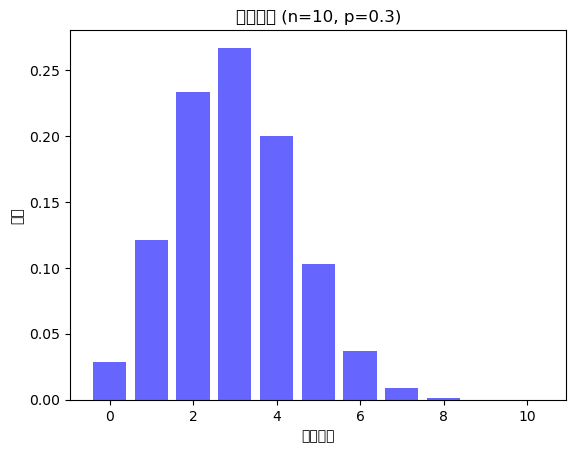

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27850 (\N{CJK UNIFIED IDEOGRAPH-6CCA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26494 (\N{CJK UNIFIED IDEOGRAPH-677E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


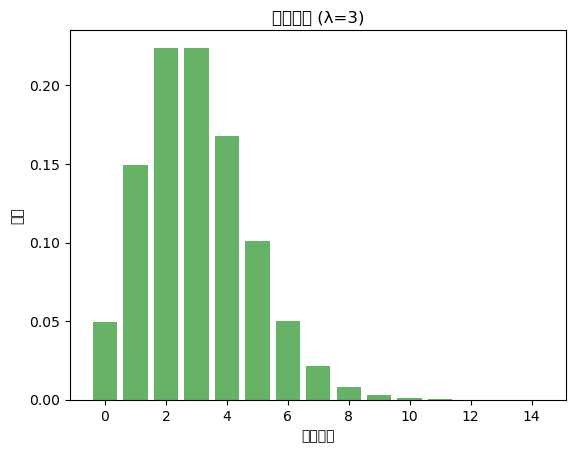

In [30]:
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson
import numpy as np

# 二项分布
n, p = 10, 0.3
x_binom = np.arange(0, n+1)
y_binom = binom.pmf(x_binom, n, p)
plt.bar(x_binom, y_binom, alpha=0.6, color='blue')
plt.title('二项分布 (n=10, p=0.3)')
plt.xlabel('成功次数')
plt.ylabel('概率')
plt.show()

# 泊松分布
lambda_ = 3
x_poisson = np.arange(0, 15)
y_poisson = poisson.pmf(x_poisson, lambda_)
plt.bar(x_poisson, y_poisson, alpha=0.6, color='green')
plt.title('泊松分布 (λ=3)')
plt.xlabel('事件次数')
plt.ylabel('概率')
plt.show()


In [33]:
import numpy as np
import pandas as pd

# Parameters for the binomial distribution
n = 10   # number of trials
p = 0.5  # probability of success
size = 1000  # number of samples

# Generate binomial samples
data = np.random.binomial(n, p, size)

# Put into a pandas DataFrame for convenience
df = pd.DataFrame({"binomial": data})


In [34]:
df

,binomial
0,3
1,5
2,6
3,3
4,3
...,...
995,4
996,7
997,5
998,3


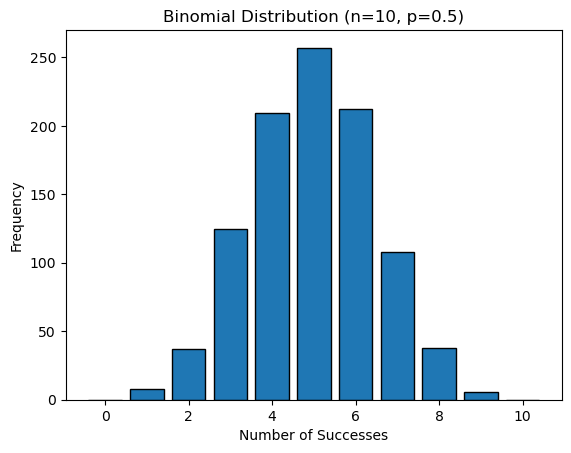

In [35]:
import matplotlib.pyplot as plt

plt.hist(df["binomial"], bins=range(n+2), align="left", rwidth=0.8, edgecolor="black")
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.title("Binomial Distribution (n=10, p=0.5)")
plt.show()


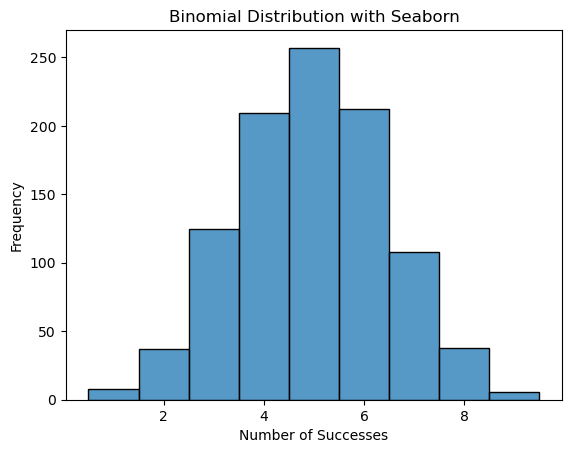

In [36]:
import seaborn as sns

sns.histplot(df["binomial"], bins=range(n+2), discrete=True)
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.title("Binomial Distribution with Seaborn")
plt.show()
